# **Customer Churn Propensity Model**
### AI for Communication and Marketing

**Academic Year:** 2025/2026  
**Course:** B.Sc. in Artificial Intelligence  
**Student:** Irene Marrali                           
**Dataset:** `data.xlsx`

## Business Objective

The objective of this project is to **develop a propensity model** capable of identifying e-commerce customers who are at risk of churning.

The analysis will include data quality checks, exploratory data analysis, preprocessing, predictive modeling and model evaluation. The final goal is to identify the main churn drivers and translate the model results into **actionable marketing recommendations for customer retention.**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## Dataset Loading

The dataset is loaded. The first five observations are displayed to verify that the file has been imported correctly.

In [2]:
file_path = "data.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="E Comm"  # Load the "E Comm" worksheet into a pandas DataFrame
)

print("Dataset loaded successfully.")

# Display the first five rows of the dataset
df.head()

Dataset loaded successfully.


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001.0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002.0,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003.0,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004.0,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005.0,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [3]:
# Display the number of customers and variables
# Inspect column names, data types, and non-null values
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (5630, 20)
<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5628 non-null   float64
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5628 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  Num

### Initial Dataset Inspection

The dataset contains **5,630 customer records and 20 variables**, including demographic, behavioral, transactional and satisfaction-related information. The target variable, `Churn`, is complete and stored as an integer, while the dataset includes both numerical and categorical predictors.

The initial inspection also reveals that several variables contain **missing values**, especially `Tenure`, `WarehouseToHome`, `HourSpendOnApp`, `OrderAmountHikeFromlastYear`, `CouponUsed`, `OrderCount` and `DaySinceLastOrder`. In addition, `CustomerID` is stored as a floating-point variable because of two missing values, although it represents an identifier rather than a predictive feature.

Overall, the dataset is suitable for churn modeling, but it requires a structured data quality assessment before the exploratory analysis and model development stages.

## Data Audit and Quality
This section assesses **the overall quality of the dataset before model development.** The audit focuses on missing values, duplicate records, inconsistent categorical labels, implausible numerical values and potential outliers.

The cleaning strategy is designed to preserve as much useful customer information as possible. Missing numerical values will generally be imputed using robust statistics, while inconsistent categorical labels will be standardized. Clearly implausible values will be treated separately from valid but unusual observations.

### Descriptive Statistics

Descriptive statistics are used to summarize the distribution of numerical and categorical variables. This inspection helps identify unusual ranges, highly dispersed variables, dominant categories and potentially implausible values before applying any cleaning procedure.

In [4]:
# Display descriptive statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,5628.0,52814.549041,1624.890759,50001.0,51407.75,52814.50,54221.2500,55630.0
Churn,5630.0,0.168384,0.374240,0.0,0.00,0.00,0.0000,1.0
Tenure,5366.0,10.189899,8.557241,0.0,2.00,9.00,16.0000,61.0
CityTier,5630.0,1.654707,0.915389,1.0,1.00,1.00,3.0000,3.0
WarehouseToHome,5379.0,15.639896,8.531475,5.0,9.00,14.00,20.0000,127.0
HourSpendOnApp,5375.0,2.931535,0.721926,0.0,2.00,3.00,3.0000,5.0
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.00,4.00,4.0000,6.0
SatisfactionScore,5630.0,3.066785,1.380194,1.0,2.00,3.00,4.0000,5.0
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.00,3.00,6.0000,22.0
Complain,5630.0,0.284902,0.451408,0.0,0.00,0.00,1.0000,1.0


The numerical summary confirms that most variables have plausible ranges, but it also highlights some potential data quality issues.

- `Churn` has a mean of approximately 0.168, indicating that around 16.8% of customers churned. This suggests **a class imbalance**, with non-churners representing the majority of the dataset.
- `Tenure` ranges from 0 to 61 months. Although the maximum is relatively high compared with the median of 9 months, it remains plausible and should not be treated as an error without further evidence.
- `WarehouseToHome` ranges from 5 to 127, while the third quartile is only 20. This large gap suggests **the presence of extreme values** that require further inspection.
- `CashbackAmount` presents the clearest anomaly. Its maximum value is 999,999, while the median is approximately 163.33. The extremely large standard deviation also confirms that **one or more implausible values strongly distort the distribution.**

Variables such as `CouponUsed`, `OrderCount`, `DaySinceLastOrder` and `NumberOfAddress` also show relatively high maximum values compared with their quartiles. These observations should be inspected as potential outliers, but they should not be removed automatically because they may represent valid customer behavior.

In [5]:
# Descriptive statistics for categorical variables
categorical_summary = df.describe(include=["object", "string"]).T
display(categorical_summary)

,count,unique,top,freq
PreferredLoginDevice,5630,4,Mobile Phone,2763
PreferredPaymentMode,5630,7,Debit Card,2314
Gender,5628,2,Male,3383
PreferedOrderCat,5630,6,Laptop & Accessory,2050
MaritalStatus,5630,4,Married,2984


The categorical summary shows that all categorical variables contain a limited number of distinct categories, which makes them suitable for encoding. Although the number of categories is manageable, the frequency table alone is not sufficient to detect inconsistent labels. Therefore, the unique values and their counts should be inspected separately before applying categorical encoding.

### Missing Values Analysis

Missing values are quantified both as absolute counts and percentages. This assessment is essential because untreated missing data can distort descriptive statistics, reduce model reliability and introduce bias during training.
Based on their frequency and meaning, missing values can be handled through **removal or imputation**. Removing rows or columns is appropriate only when the information loss is limited, while imputation helps preserve useful customer records when the proportion of missing values is relatively low. The final choice should minimize unnecessary data loss without introducing unrealistic values.

In [6]:
# Count missing values for each variable
missing_count = df.isna().sum()

# Calculate the percentage of missing values
missing_percentage = (missing_count / len(df)) * 100

# Create a summary table
missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percentage
})

# Display only variables containing missing values
missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_summary.round(2)

,Missing Values,Missing Percentage
DaySinceLastOrder,307,5.45
OrderAmountHikeFromlastYear,265,4.71
Tenure,264,4.69
OrderCount,258,4.58
CouponUsed,256,4.55
HourSpendOnApp,255,4.53
WarehouseToHome,251,4.46
CustomerID,2,0.04
Gender,2,0.04


The missing-value percentages are relatively low, ranging **from approximately 4.5% to 5.5%** for the most affected variables. Therefore, removing all incomplete observations would lead to unnecessary information loss and could reduce the representativeness of the dataset.

The imputation step will be performed **only after the outlier and consistency analysis.** This is important because clearly anomalous values could distort the distribution of the variables and influence the imputation statistics.

For the numerical variables, median imputation is planned because **the median** is more robust than the mean in the presence of skewed distributions and extreme values. For the categorical variable `Gender`, **the most frequent category** will be used because only two observations are missing and the missing proportion is negligible.

`CustomerID` will not be imputed for modeling purposes because it is only an identifier and will be excluded from the predictive features.

### Duplicate Records and Customer Identifiers

Duplicate observations are checked to ensure that each row represents a distinct customer and that no customer is unintentionally counted more than once. Duplicate records could distort descriptive statistics, class proportions and model training by giving excessive weight to repeated observations.

In [7]:
# Count fully duplicated rows
duplicated_rows = df.duplicated().sum()

# Count duplicated valid customer identifiers
duplicated_customer_ids = df["CustomerID"].dropna().duplicated().sum()

print("Fully duplicated rows:", duplicated_rows)
print("Duplicated non-missing CustomerIDs:", duplicated_customer_ids)

Fully duplicated rows: 0
Duplicated non-missing CustomerIDs: 0


No fully duplicated records or repeated valid customer identifiers were detected. Therefore, no observations need to be removed because of duplication. `CustomerID` will be retained temporarily for traceability, but it will later be excluded from the predictive features because it is a unique identifier and does not represent customer behavior.

### Categorical Data Consistency

Categorical variables are inspected to identify spelling differences, abbreviations and labels that may represent the same underlying category. Inconsistent labels must be standardized before encoding, otherwise the model would treat equivalent categories as distinct features.

In [8]:
# Identify categorical variables
categorical_columns = df.select_dtypes(
    include=["object", "string"]
).columns

# Display unique values and frequencies for each categorical variable
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False))


PreferredLoginDevice
PreferredLoginDevice
Mobile Phone    2763
Computer        1632
Phone           1230
N.A.               5
Name: count, dtype: int64

PreferredPaymentMode
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

Gender
Gender
Male      3383
Female    2245
NaN          2
Name: count, dtype: int64

PreferedOrderCat
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     2984
Single      1795
Divorced     848
Widow          3
Name: count, dtype: int64


The inspection reveals several inconsistent labels that **refer to the same underlying category:** 
- `Phone` and `Mobile Phone` represent the same login device;
- `CC` and `Credit Card` indicate the same payment method. Similarly;
- `Cash on Delivery` and `COD` are equivalent
- `Mobile` and `Mobile Phone` represent the same preferred order category.

These labels must be standardized before encoding; otherwise, the model would incorrectly treat equivalent categories as separate features.

The value `N.A.` in `PreferredLoginDevice` is not a meaningful category and will therefore be converted into a missing value. The rare category `Widow` is retained because it is valid, even though it appears only three times.

In [9]:
# Create a copy of the original dataset before applying cleaning operations
df_clean = df.copy()

# Convert the textual placeholder "N.A." into a real missing value
df_clean["PreferredLoginDevice"] = df_clean[
    "PreferredLoginDevice"
].replace("N.A.", np.nan)

# Standardize equivalent login-device labels
df_clean["PreferredLoginDevice"] = df_clean[
    "PreferredLoginDevice"
].replace({
    "Phone": "Mobile Phone"
})

# Standardize equivalent payment-mode labels
df_clean["PreferredPaymentMode"] = df_clean[
    "PreferredPaymentMode"
].replace({
    "CC": "Credit Card",
    "Cash on Delivery": "COD"
})

# Standardize equivalent preferred-order-category labels
df_clean["PreferedOrderCat"] = df_clean[
    "PreferedOrderCat"
].replace({
    "Mobile": "Mobile Phone"
})

# Recheck categorical values after standardization
for column in categorical_columns:
    print(f"\n{column}")
    print(df_clean[column].value_counts(dropna=False))


PreferredLoginDevice
PreferredLoginDevice
Mobile Phone    3993
Computer        1632
NaN                5
Name: count, dtype: int64

PreferredPaymentMode
PreferredPaymentMode
Debit Card     2314
Credit Card    1774
E wallet        614
COD             514
UPI             414
Name: count, dtype: int64

Gender
Gender
Male      3383
Female    2245
NaN          2
Name: count, dtype: int64

PreferedOrderCat
PreferedOrderCat
Mobile Phone          2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     2984
Single      1795
Divorced     848
Widow          3
Name: count, dtype: int64


After standardization, equivalent labels have been successfully merged and each categorical variable now contains **a consistent set of categories.**

The five `N.A.` values in `PreferredLoginDevice` have been correctly converted into missing values, while the two missing values in `Gender` remain unchanged. These missing categorical observations will be handled later through most-frequent imputation.

No further categorical inconsistencies were detected.

### Outlier Detection

Numerical variables are examined to identify unusual ranges, extreme observations and potential data-entry errors. The analysis focuses especially on `Tenure` and `WarehouseToHome`, as required by the project instructions, while also considering other variables whose distributions suggest possible anomalies.

Outliers are not removed automatically. Some extreme values may represent valid customer behavior and could still provide useful information for churn prediction. Therefore, descriptive statistics and the most extreme observations are inspected first to distinguish plausible but rare values from clearly implausible records. Only after this inspection will an appropriate treatment strategy be defined.

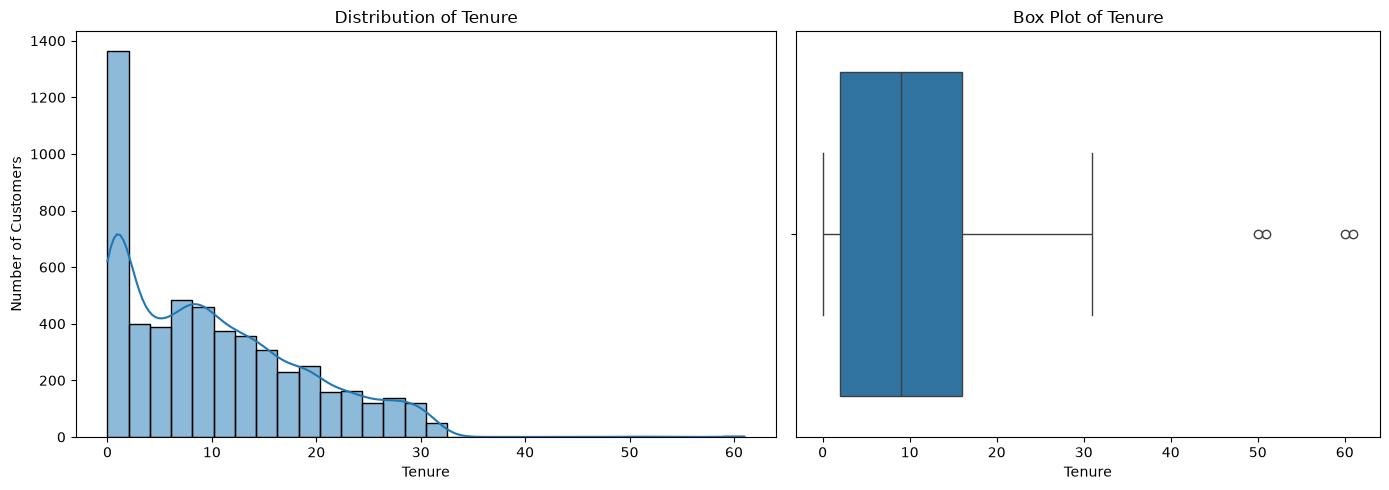

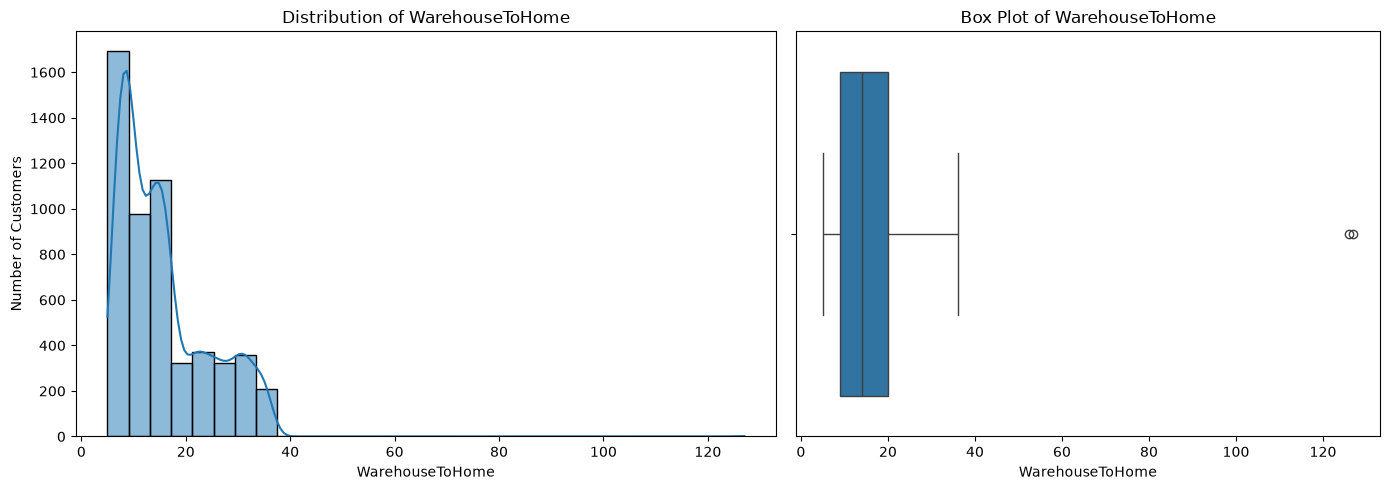

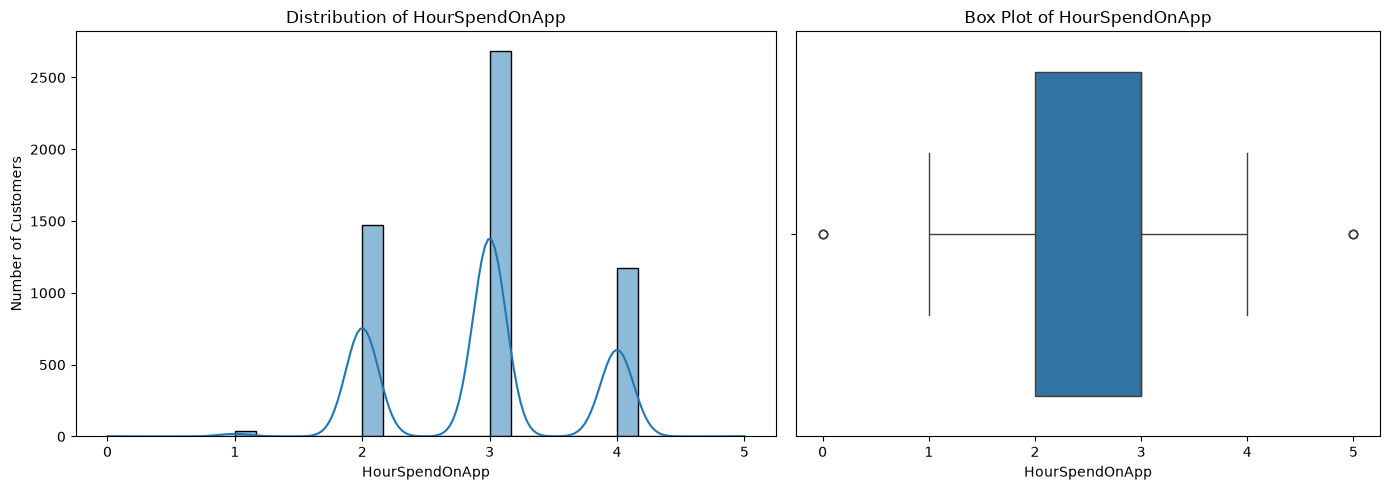

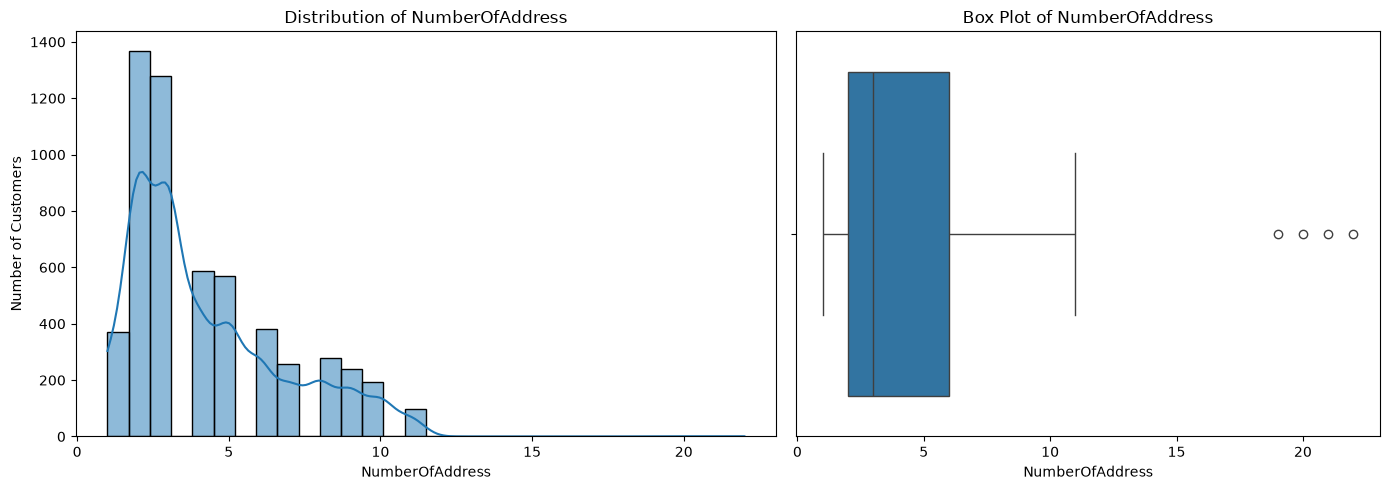

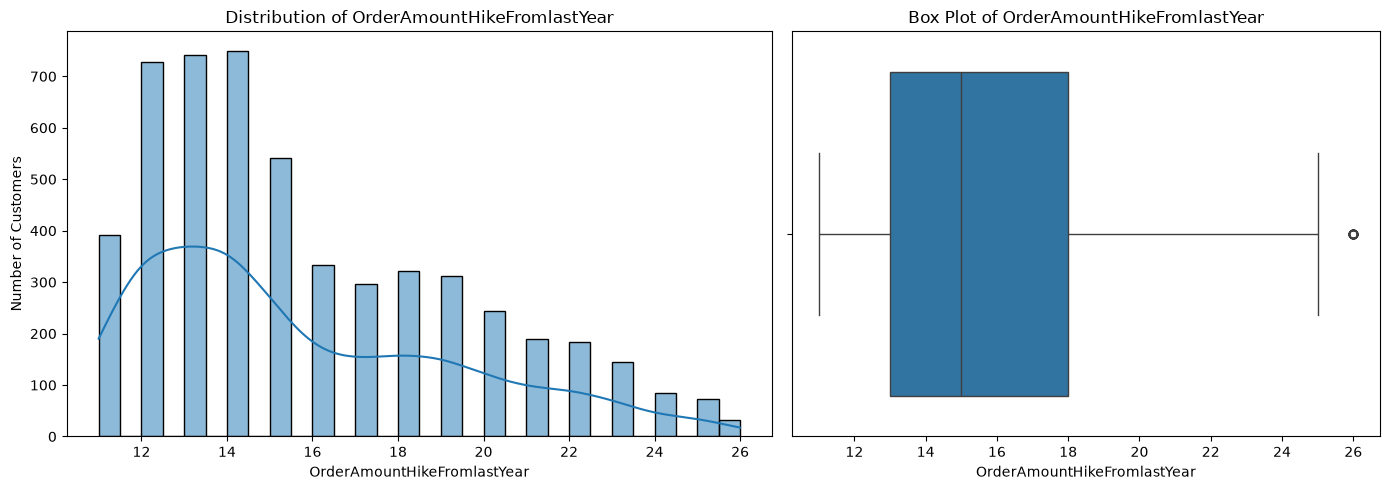

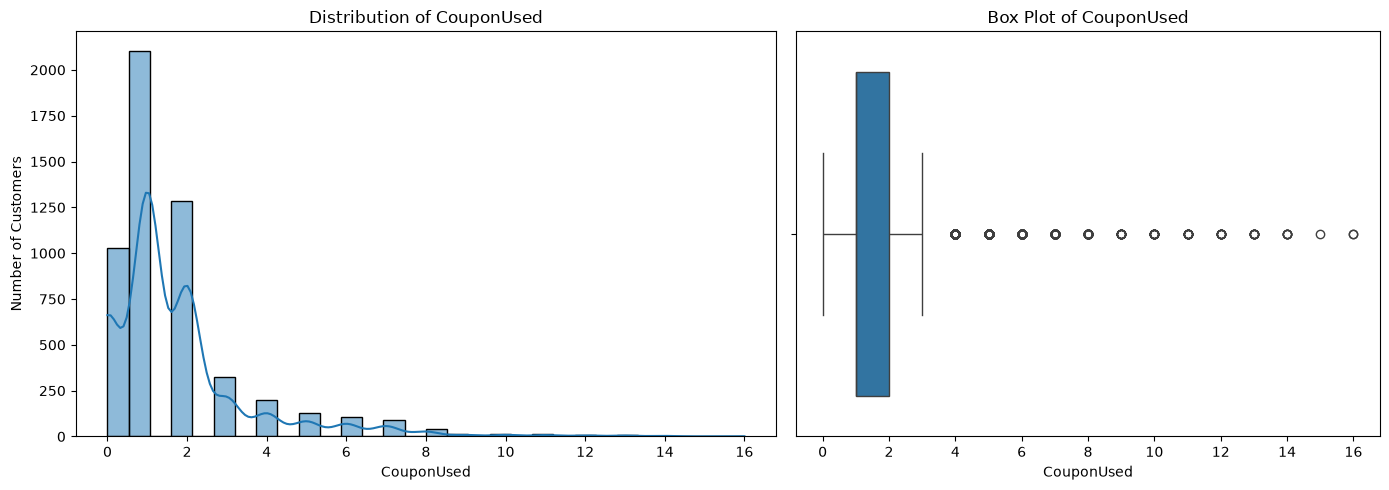

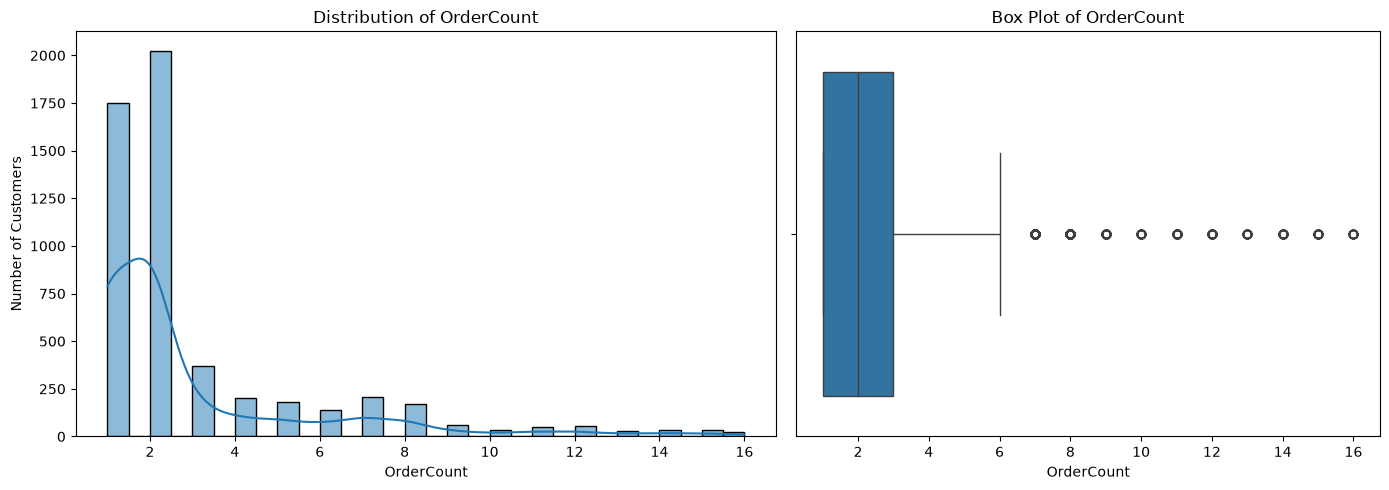

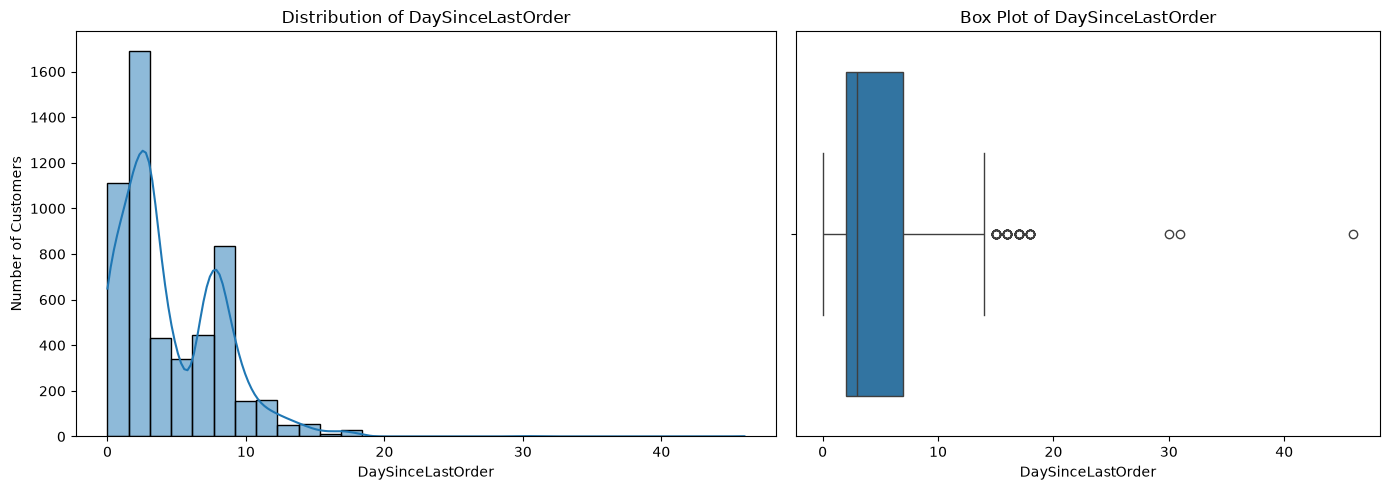

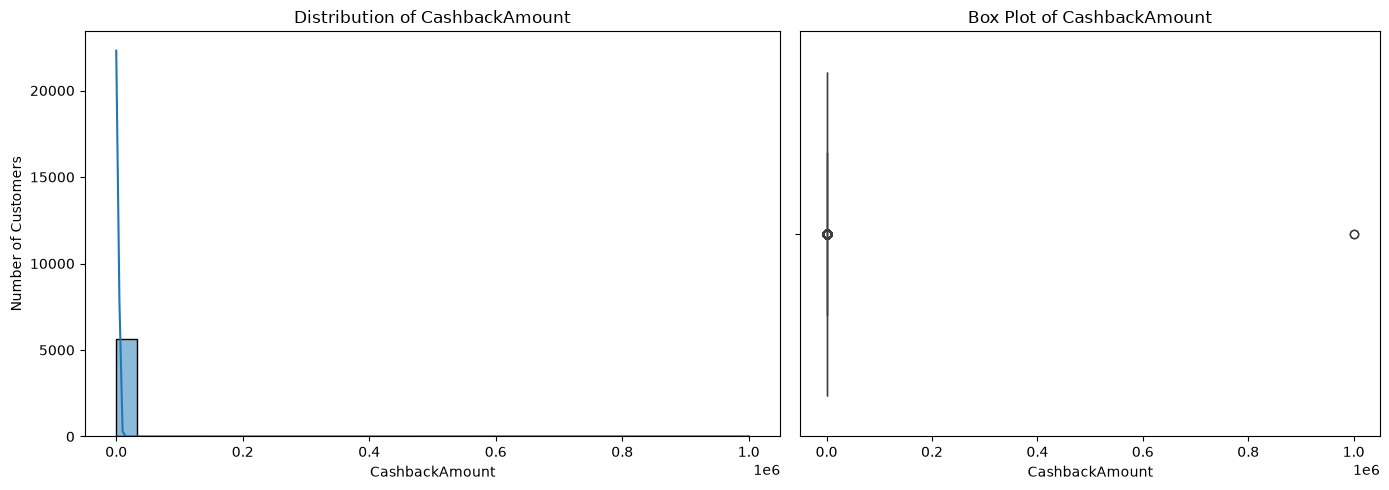

In [10]:
# Import seaborn for clearer statistical visualizations
import seaborn as sns

# Select the numerical variables to inspect
variables_to_inspect = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfAddress",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount"
]

# Create one combined figure for each numerical variable
for column in variables_to_inspect:
    
    # Create a figure with two side-by-side plots
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5),
        gridspec_kw={"width_ratios": [1.2, 1]}
    )

    # Plot the distribution with a density curve
    sns.histplot(
        data=df_clean,
        x=column,
        bins=30,
        kde=True,
        ax=axes[0]
    )

    axes[0].set_title(f"Distribution of {column}")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Number of Customers")

    # Create the corresponding horizontal box plot
    sns.boxplot(
        data=df_clean,
        x=column,
        ax=axes[1]
    )

    axes[1].set_title(f"Box Plot of {column}")
    axes[1].set_xlabel(column)

    # Improve spacing between the two plots
    plt.tight_layout()
    plt.show()

The visual inspection shows that several numerical variables are right-skewed and contain observations beyond the box-plot whiskers. However, these values are not automatically considered errors, because some may represent valid but uncommon customer behavior.

- `Tenure` shows a right-skewed distribution, but its maximum value of 61 months remains plausible and is therefore retained. 
- `WarehouseToHome` contains a small number of values around 126–127, which are clearly separated from the rest of the distribution and require further inspection.
- `CashbackAmount` presents the strongest anomaly, with values equal to 999,999 that heavily distort both the histogram and the box plot. These observations are implausible compared with the central distribution and are likely data-entry errors.

Variables such as `CouponUsed`, `OrderCount`, `DaySinceLastOrder` and `NumberOfAddress` contain statistical outliers, but their values remain plausible and may reflect genuine customer behavior. Therefore, they are retained at this stage.

In [11]:
# Inspect the most extreme values of the variables that show clear anomalies
for column in ["WarehouseToHome", "CashbackAmount", "Tenure"]:
    print(f"\nLargest values for {column}:")
    display(
        df_clean[
            ["CustomerID", column]
        ].sort_values(
            by=column,
            ascending=False
        ).head(10)
    )


Largest values for WarehouseToHome:


,CustomerID,WarehouseToHome
4124,54125.0,127.0
1309,51310.0,126.0
5586,55587.0,36.0
3763,53764.0,36.0
4419,54420.0,36.0
5025,55026.0,36.0
5390,55391.0,36.0
4359,54360.0,36.0
4364,54365.0,36.0
5434,55435.0,36.0



Largest values for CashbackAmount:


,CustomerID,CashbackAmount
5518,55519.0,999999.00
590,50591.0,999999.00
4350,54351.0,324.99
2880,52881.0,324.99
3436,53437.0,324.73
4906,54907.0,324.73
3541,53542.0,324.43
5011,55012.0,324.43
2855,52856.0,324.26
4325,54326.0,324.26



Largest values for Tenure:


,CustomerID,Tenure
5534,55535.0,61.0
2719,52720.0,60.0
3743,53744.0,51.0
928,50929.0,50.0
3899,53900.0,31.0
4166,54167.0,31.0
4323,54324.0,31.0
4317,54318.0,31.0
4064,54065.0,31.0
5169,55170.0,31.0


The inspection identified four observations containing clearly implausible values: two `WarehouseToHome` values equal to 126 and 127, and two `CashbackAmount` values equal to 999,999.

These values are strongly separated from the remaining distributions and **are considered likely data-entry errors.** Since the affected records represent only a negligible proportion of the dataset, **the corresponding rows are removed.**

Other extreme values, such as high `Tenure`, `CouponUsed` or `OrderCount`, are retained because they remain plausible and may reflect genuine customer behavior.

In [12]:
# Remove rows containing clearly implausible numerical values
df_clean = df_clean[
    ~(
        (df_clean["WarehouseToHome"] > 100) |
        (df_clean["CashbackAmount"] == 999999)
    )
].copy()

# Reset the row index after removal
df_clean.reset_index(drop=True, inplace=True)

print("Dataset shape after outlier removal:", df_clean.shape)

Dataset shape after outlier removal: (5626, 20)


### Missing Value Imputation

After removing the clearly implausible outliers, the remaining missing values are handled through imputation.
- `CustomerID` is a unique identifier and cannot be meaningfully imputed using statistical methods. Since only two observations have a missing `CustomerID`, these rows are removed before imputing the remaining variables. 
- Numerical variables are imputed using the median because it is more robust than the mean.
- Categorical variables are imputed using the most frequent category because the number of missing observations is very limited.

In [13]:
# Remove observations with a missing customer identifier
df_clean = df_clean.dropna(subset=["CustomerID"]).copy()

# Reset the index after removing observations
df_clean.reset_index(drop=True, inplace=True)

print("Dataset shape after removing missing CustomerID values:", df_clean.shape)

Dataset shape after removing missing CustomerID values: (5624, 20)


In [14]:
# Define numerical variables with missing values
numerical_missing_columns = [
    "DaySinceLastOrder",
    "OrderAmountHikeFromlastYear",
    "Tenure",
    "OrderCount",
    "CouponUsed",
    "HourSpendOnApp",
    "WarehouseToHome"
]

# Impute missing numerical values using the median
for column in numerical_missing_columns:
    df_clean[column] = df_clean[column].fillna(
        df_clean[column].median()
    )

# Impute missing categorical values using the most frequent category
df_clean["Gender"] = df_clean["Gender"].fillna(
    df_clean["Gender"].mode()[0]
)

df_clean["PreferredLoginDevice"] = df_clean[
    "PreferredLoginDevice"
].fillna(
    df_clean["PreferredLoginDevice"].mode()[0]
)

print("Missing values imputed successfully.")

# Display the total number of remaining missing values
print("Total remaining missing values:", df_clean.isna().sum().sum())

Missing values imputed successfully.
Total remaining missing values: 0


### Feature Encoding and Scaling Strategy

Before applying categorical encoding, **the target variable `Churn` is separated** from the predictive features. `CustomerID` is also excluded because it is only a unique identifier and does not provide meaningful behavioral information for churn prediction.

The remaining categorical predictors are transformed using **One-Hot Encoding**. This method creates binary variables for each category without introducing an artificial ordinal relationship between labels. One reference category is dropped for each original variable to reduce redundancy and limit multicollinearity.

The target variable remains unchanged, while the resulting feature matrix contains only numerical values and is therefore suitable for machine learning algorithms.

In [15]:
# Separate the target variable from the predictive features
y = df_clean["Churn"]

# Remove the target variable and the customer identifier
X = df_clean.drop(columns=["Churn", "CustomerID"])

# Identify categorical predictive features
categorical_columns = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

# Apply One-Hot Encoding only to categorical predictive features
X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

# Display the resulting dimensions
print("Original feature matrix shape:", X.shape)
print("Encoded feature matrix shape:", X_encoded.shape)
print("Target vector shape:", y.shape)

# Check for missing values in the encoded feature matrix
print(
    "Total missing values in X_encoded:",
    X_encoded.isna().sum().sum()
)

Original feature matrix shape: (5624, 18)
Encoded feature matrix shape: (5624, 26)
Target vector shape: (5624,)
Total missing values in X_encoded: 0


After all the preprocessing techniques, the final dataset contains **5,624 complete customer records** and is ready for exploratory data analysis and predictive modeling.

## Exploratory Data Analysis (EDA)

This section explores the relationships **between customer characteristics and churn behavior.** The analysis focuses on the variables explicitly required by the project:

- the relationship between `Complain`, `SatisfactionScore` and `Churn`;
- the influence of `Tenure` and `DaySinceLastOrder` on churn;
- the balance between churners and non-churners.

The objective is to identify preliminary churn patterns and **generate insights** that can later support model interpretation and marketing recommendations.

### Class Balance

The distribution of the target variable `Churn` is examined to determine whether **the dataset is balanced.** Class imbalance is particularly important in churn prediction because churners usually represent a smaller proportion of the customer base. In this context, accuracy alone may be misleading, as a model could achieve high accuracy by mostly predicting the majority class.

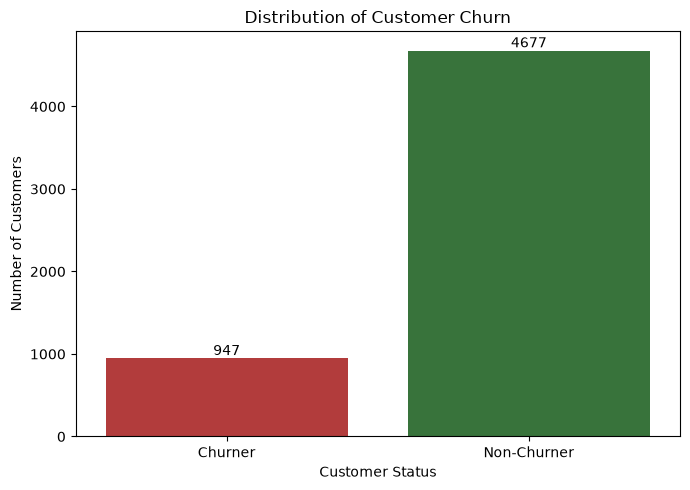

In [16]:
# Create readable labels for the target classes
churn_labels = df_clean["Churn"].map({
    0: "Non-Churner",
    1: "Churner"
})

# Plot the churn distribution using distinct colors
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    x=churn_labels,
    hue=churn_labels,
    order=["Churner", "Non-Churner"],
    palette={
        "Churner": "#C62828",   # red,
        "Non-Churner": "#2E7D32"  # dark green
    },
    legend=False
)

# Add customer counts above each bar
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Customer Churn")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

The target distribution shows that non-churners represent the majority of the customer base. Therefore, **the dataset is moderately imbalanced.** This imbalance must be considered during model development because a model focused mainly on the majority class could fail to identify a substantial proportion of customers at risk.

For this reason, the train-test split will be **stratified** and model performance will be evaluated using metrics such as **Recall, Precision, F1-Score** and Lift rather than relying only on Accuracy.

### Complaints, Satisfaction and Churn

This analysis examines whether customer complaints and satisfaction levels are associated with churn.
1. `Complain` indicates whether a customer raised a complaint in the last month,
2. `SatisfactionScore` measures the customer's level of satisfaction with the service. 

Comparing churn rates across these variables helps identify whether **dissatisfaction and service issues are relevant risk signals.**

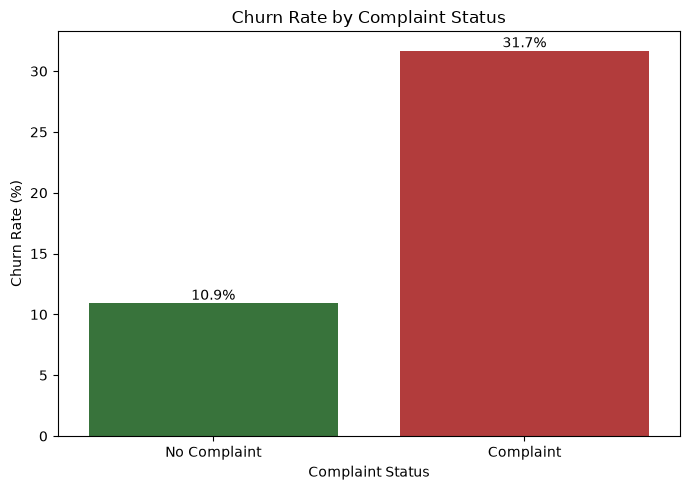

In [17]:
# Calculate churn rate by complaint status
complain_churn_rate = (
    df_clean.groupby("Complain")["Churn"]
    .mean()
    .mul(100)
    .reset_index()
)

# Create readable complaint labels
complain_churn_rate["Complaint Status"] = complain_churn_rate["Complain"].map({
    0: "No Complaint",
    1: "Complaint"
})

# Plot churn rate by complaint status
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=complain_churn_rate,
    x="Complaint Status",
    y="Churn",
    hue="Complaint Status",
    palette={
        "No Complaint": "#2E7D32",  # dark green,
        "Complaint": "#C62828"   # red
    },
    legend=False
)

# Add percentage labels above the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Churn Rate by Complaint Status")
plt.xlabel("Complaint Status")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

**Customers who submitted a complaint show a substantially higher churn rate than those who did not.** Approximately **31.7%** of customers with a complaint churned, compared with only **10.9%** among customers without complaints.

This large difference suggests that **complaints are a strong signal of customer dissatisfaction and potential churn risk.** From a marketing perspective, customers who recently raised a complaint should be prioritized for timely customer-service follow-up and targeted retention actions. However, this relationship should be interpreted as an association rather than direct causation.

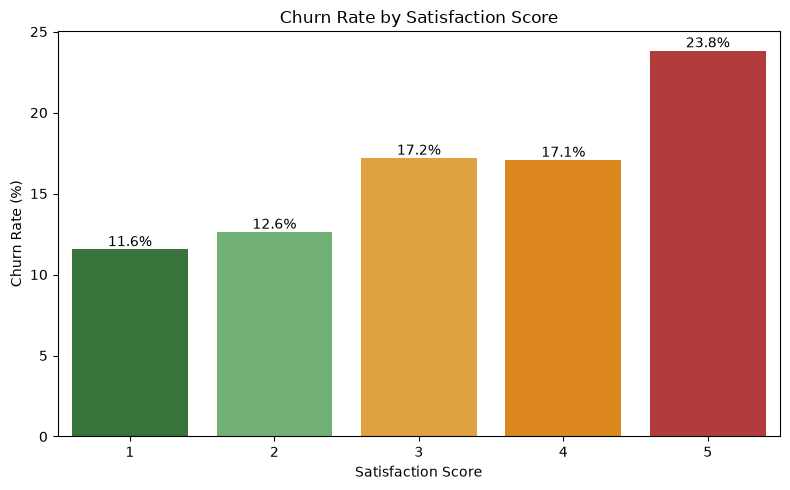

In [18]:
# Calculate churn rate by satisfaction score
satisfaction_churn_rate = (
    df_clean.groupby("SatisfactionScore")["Churn"]
    .mean()
    .mul(100)
    .reset_index()
)

# Define colors from lower to higher churn risk
risk_colors = [
    "#2E7D32",  # dark green
    "#66BB6A",  # light green
    "#F9A825",  # amber
    "#FB8C00",  # orange
    "#C62828"   # red
]

# Plot churn rate by satisfaction score
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=satisfaction_churn_rate,
    x="SatisfactionScore",
    y="Churn",
    hue="SatisfactionScore",
    palette=risk_colors,
    legend=False
)

# Add percentage labels above the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Churn Rate by Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

The observed relationship between `SatisfactionScore` and churn is not monotonic. Customers with scores of 1 and 2 show the lowest churn rates, while the churn rate increases for scores of 3 and 4 and reaches its highest level among customers with a score of 5.

This pattern is **counterintuitive**, since higher satisfaction would normally be expected to correspond to lower churn. Therefore, the satisfaction score should not be interpreted in isolation. Its relationship with churn **may depend on other customer characteristics, particularly whether the customer has recently submitted a complaint.**

In [19]:
# Calculate churn rate by satisfaction score and complaint status
satisfaction_complaint_summary = (
    df_clean.groupby(
        ["SatisfactionScore", "Complain"]
    )["Churn"]
    .mean()
    .mul(100)
    .reset_index()
)

satisfaction_complaint_summary

,SatisfactionScore,Complain,Churn
0,1,0,7.088608
1,1,1,21.081081
2,2,0,7.692308
3,2,1,24.705882
4,3,0,10.440457
5,3,1,34.745763
6,4,0,9.925558
7,4,1,38.721805
8,5,0,18.320611
9,5,1,37.267081


The joint analysis clarifies that **complaint behavior is strongly associated with churn across every satisfaction level**. For each `SatisfactionScore`, customers who submitted a complaint have a substantially higher churn rate than customers with the same score but no complaint.

This indicates that `Complain` is a more consistent churn-risk signal than `SatisfactionScore`. The satisfaction score alone does not show a simple linear relationship with customer loyalty, whereas recent complaints clearly distinguish higher-risk customers from lower-risk customers.

From a marketing perspective, customers who recently raised a complaint should be prioritized for service recovery and retention actions, regardless of their reported satisfaction score.

### Tenure, Recency and Churn

This analysis examines whether **customer tenure and the number of days since the last order** are associated with churn.

- `Tenure` captures the duration of the customer relationship;
- `DaySinceLastOrder` reflects purchase recency. 

Grouping these variables into intervals makes it easier to observe how churn risk changes across different customer lifecycle stages.

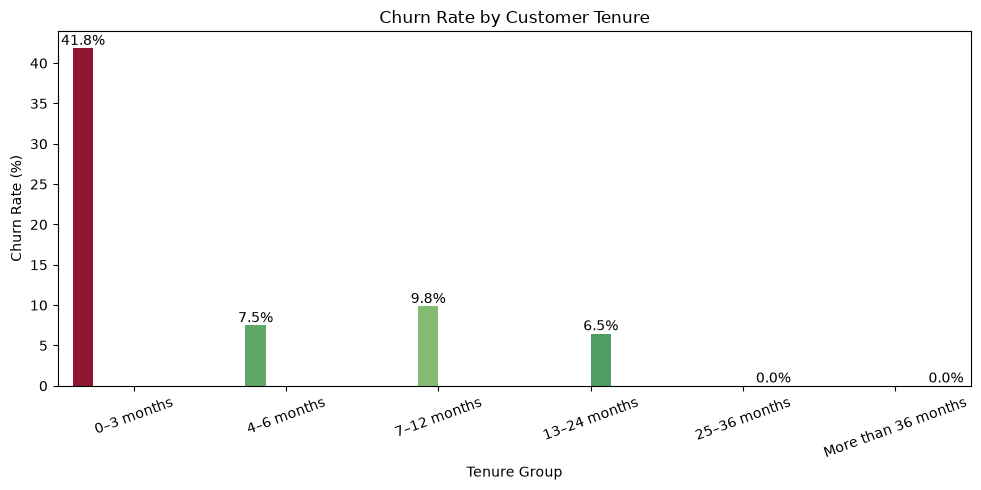

In [20]:
# Group customer tenure into meaningful intervals
df_clean["TenureGroup"] = pd.cut(
    df_clean["Tenure"],
    bins=[-1, 3, 6, 12, 24, 36, np.inf],
    labels=[
        "0–3 months",
        "4–6 months",
        "7–12 months",
        "13–24 months",
        "25–36 months",
        "More than 36 months"
    ]
)

# Calculate churn rate for each tenure group
tenure_churn_rate = (
    df_clean.groupby("TenureGroup", observed=False)["Churn"]
    .mean()
    .mul(100)
    .reset_index()
)

# Create a color scale based on the observed churn rate
tenure_norm = plt.Normalize(
    tenure_churn_rate["Churn"].min(),
    tenure_churn_rate["Churn"].max()
)

tenure_colors = {
    row["TenureGroup"]: plt.cm.RdYlGn_r(
        tenure_norm(row["Churn"])
    )
    for _, row in tenure_churn_rate.iterrows()
}

# Plot churn rate by tenure group
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=tenure_churn_rate,
    x="TenureGroup",
    y="Churn",
    hue="TenureGroup",
    palette=tenure_colors,
    legend=False
)

# Add percentage labels above the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The churn rate is **highest among customers with a tenure of 0–3 months**, reaching approximately 41.8%. This indicates that the earliest stage of the customer relationship is **the most critical period for retention.**

After the first three months, churn decreases sharply. Customers with a tenure between 4 and 24 months show churn rates below 10%, while no churn is observed among customers with more than 24 months of tenure.

This pattern suggests that **customers become substantially more stable as their relationship with the company develops.** From a marketing perspective, retention actions should therefore focus particularly on newly acquired customers through onboarding support, early engagement campaigns and targeted incentives during the first months.

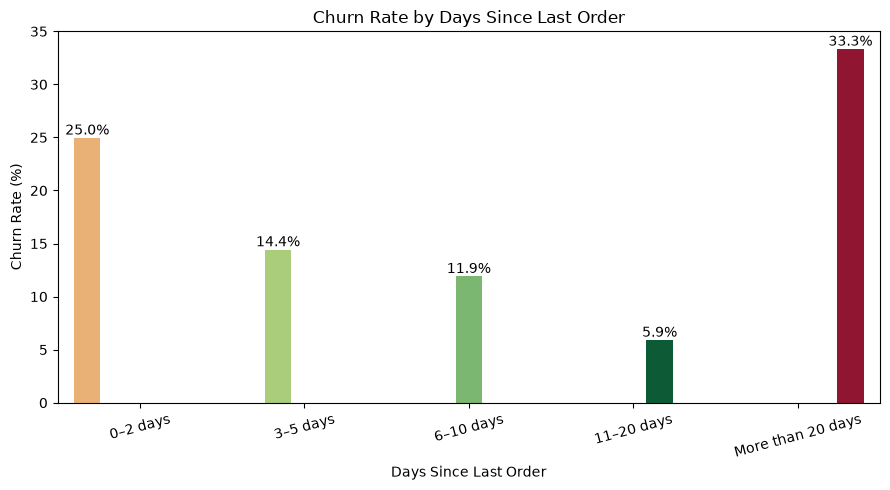

In [21]:
# Group days since last order into meaningful intervals
df_clean["RecencyGroup"] = pd.cut(
    df_clean["DaySinceLastOrder"],
    bins=[-1, 2, 5, 10, 20, np.inf],
    labels=[
        "0–2 days",
        "3–5 days",
        "6–10 days",
        "11–20 days",
        "More than 20 days"
    ]
)

# Calculate churn rate for each recency group
recency_churn_rate = (
    df_clean.groupby("RecencyGroup", observed=False)["Churn"]
    .mean()
    .mul(100)
    .reset_index()
)

# Create a color scale based on the observed churn rate
recency_norm = plt.Normalize(
    recency_churn_rate["Churn"].min(),
    recency_churn_rate["Churn"].max()
)

recency_colors = {
    row["RecencyGroup"]: plt.cm.RdYlGn_r(
        recency_norm(row["Churn"])
    )
    for _, row in recency_churn_rate.iterrows()
}

# Plot churn rate by recency group
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=recency_churn_rate,
    x="RecencyGroup",
    y="Churn",
    hue="RecencyGroup",
    palette=recency_colors,
    legend=False
)

# Add percentage labels above the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Churn Rate by Days Since Last Order")
plt.xlabel("Days Since Last Order")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

The relationship between purchase recency and churn is **not fully linear.** Customers whose last order occurred more than 20 days ago show the highest churn rate, at approximately 33.3%, suggesting that **prolonged inactivity is a strong warning signal.**

A relatively high churn rate is also observed among customers who ordered within the last 0–2 days, at approximately 25%. Churn then decreases progressively across the **intermediate groups**, reaching its lowest level among customers whose last order occurred 11–20 days ago.

The high churn rate in the 0–2 day group is counterintuitive and may reflect interactions with other factors, such as **recent complaints, unsuccessful purchases or short customer tenure**. Therefore, recency should not be interpreted in isolation.

From a marketing perspective, customers inactive for more than 20 days represent the clearest group for reactivation campaigns, while recently active customers with additional risk signals may require separate investigation.

## Modeling and Evaluation

This section develops and compares **three propensity models** to predict customer churn:

1. Logistic Regression, an interpretable linear baseline;
2. Random Forest, an ensemble model able to capture non-linear relationships;
3. XGBoost, a boosting algorithm that sequentially improves prediction errors.

The data will be divided into **stratified training and testing sets**, preserving the original churn proportion. Model performance will be evaluated using the Confusion Matrix, Precision, Recall, F1-Score, ROC-AUC and Lift.

Particular attention will be given to Recall, because **failing to identify a real churner may result in the loss of future customer value.**

In [22]:
# Split the encoded features and target into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Display the dimensions of the resulting subsets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4499, 26)
X_test shape: (1125, 26)
y_train shape: (4499,)
y_test shape: (1125,)


In [23]:
# Compare the churn proportion in the full, training and testing datasets
print(f"Full dataset churn rate: {y.mean() * 100:.2f}%")
print(f"Training set churn rate: {y_train.mean() * 100:.2f}%")
print(f"Testing set churn rate: {y_test.mean() * 100:.2f}%")

Full dataset churn rate: 16.84%
Training set churn rate: 16.85%
Testing set churn rate: 16.80%


The churn proportion remains almost identical across the full dataset, training set and testing set. This confirms that **stratification preserved the original class distribution** and produced representative subsets.

### Cross-Validation Strategy

The three models are compared using **stratified cross-validation on the training set**. Cross-validation divides the training data into multiple folds: in each iteration, the model is trained on most folds and validated on the remaining one. This process is repeated so that every fold is used for validation once.

Each model is evaluated using Recall, F1-Score and ROC-AUC. The model showing the best overall validation performance, with particular emphasis on Recall and F1-Score, will **be selected for final evaluation**. The test set remains completely unseen during model comparison and is used only once to assess the selected model on new customers.

In [24]:
# Cross-validation tools
from sklearn.model_selection import StratifiedKFold, cross_validate

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Create the Logistic Regression pipeline
logistic_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE,
                class_weight="balanced"
            )
        )
    ]
)

# Create the Random Forest pipeline
random_forest_pipeline = Pipeline(
    steps=[
        (
            "model",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced"
            )
        )
    ]
)

# Create the XGBoost pipeline
xgboost_pipeline = Pipeline(
    steps=[
        (
            "model",
            XGBClassifier(
                random_state=RANDOM_STATE,
                eval_metric="logloss"
            )
        )
    ]
)



In [25]:
# Store the models in a dictionary
models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline,
    "XGBoost": xgboost_pipeline
}

# Define stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Define evaluation metrics
scoring = {
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [26]:
# Create an empty list to store cross-validation results
cv_results = []

# Evaluate each model using stratified cross-validation
for model_name, model in models.items():
    scores = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "Mean Recall": scores["test_recall"].mean(),
        "Mean F1-Score": scores["test_f1"].mean(),
        "Mean ROC-AUC": scores["test_roc_auc"].mean()
    })

# Convert results into a comparison table
cv_results_df = pd.DataFrame(cv_results)

cv_results_df.sort_values(
    by="Mean Recall",
    ascending=False
).round(3)

,Model,Mean Recall,Mean F1-Score,Mean ROC-AUC
1,Random Forest,0.865,0.880,0.984
2,XGBoost,0.854,0.887,0.983
0,Logistic Regression,0.810,0.587,0.889


Random Forest achieved the highest mean Recall, equal to 0.865, indicating the strongest ability to **identify actual churners**. XGBoost obtained the highest mean F1-Score, equal to 0.887, while both tree-based models achieved a **very high mean ROC-AUC of approximately 0.98**.

Logistic Regression performed less effectively, especially in terms of F1-Score and ROC-AUC, suggesting that the relationship between customer features and churn is not purely linear. 

Since Recall is the main business priority in this project, **Random Forest is selected for final evaluation on the unseen test set.**

### Hyperparameter Tuning

**Randomized Search** is applied to the selected Random Forest model to identify a stronger hyperparameter configuration without testing every possible combination. This makes it more computationally efficient when the search space contains several parameters and many possible values.

The search is performed only on the training set using stratified cross-validation. Recall is used as the optimization metric because identifying as many actual churners as possible is the main business priority.

In [27]:
# Define the Random Forest hyperparameter search space
random_forest_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced", "balanced_subsample"]
}

# Initialize the baseline Random Forest model
random_forest_model = RandomForestClassifier(
    random_state=RANDOM_STATE
)

# Configure the randomized search
random_search_rf = RandomizedSearchCV(
    estimator=random_forest_model,
    param_distributions=random_forest_param_grid,
    n_iter=30,
    scoring="recall",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

# Run hyperparameter tuning on the training set
random_search_rf.fit(X_train, y_train)

# Display the best configuration and validation score
print("Best parameters:")
print(random_search_rf.best_params_)

print(f"\nBest cross-validation Recall: {random_search_rf.best_score_:.3f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}

Best cross-validation Recall: 0.883


The best Random Forest configuration achieved a **mean cross-validation Recall of 0.883**, improving on the baseline Recall of 0.865. This indicates that hyperparameter tuning **increased the model's ability to identify actual churners.**

The optimized configuration uses 100 trees, a maximum depth of 20, `min_samples_split=5`, `min_samples_leaf=1`, `max_features="sqrt"` and balanced class weights.

In [28]:
# Store the best tuned Random Forest model
best_random_forest = random_search_rf.best_estimator_

### Final Model Evaluation

The optimized Random Forest is evaluated on the unseen test set. The analysis includes **Accuracy, Precision, Recall, F1-Score, ROC-AUC and the Confusion Matrix.**

Recall remains particularly important because a false negative represents a real churner who is not identified and therefore does not receive a retention intervention.

In [29]:
# Store the best tuned Random Forest model
best_random_forest = random_search_rf.best_estimator_

# Generate class predictions on the test set
y_pred = best_random_forest.predict(X_test)

# Generate predicted churn probabilities
y_pred_proba = best_random_forest.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Create a summary table
final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

final_metrics.round(3)

,Metric,Score
0,Accuracy,0.973
1,Precision,0.877
2,Recall,0.979
3,F1-Score,0.925
4,ROC-AUC,0.998


The tuned Random Forest achieves **very strong performance on the unseen test set.**

The model reaches an **Accuracy of 0.973**, meaning that 97.3% of customers are classified correctly. However, because the dataset is imbalanced, Accuracy alone is not sufficient to assess model quality.

The Recall of **0.979** is especially important: the model correctly identifies approximately 97.9% of actual churners. The Precision of 0.877 indicates that around 87.7% of customers predicted as churners actually churned. **The F1-Score of 0.925 confirms a strong balance between Precision and Recall.**

Finally, the **ROC-AUC of 0.998** shows that the model has an excellent ability to distinguish churners from non-churners across different classification thresholds.

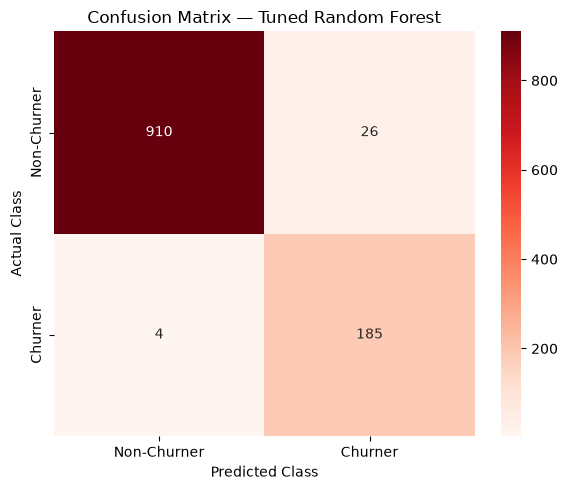

In [30]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Non-Churner", "Churner"],
    yticklabels=["Non-Churner", "Churner"]
)

plt.title("Confusion Matrix — Tuned Random Forest")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

The model correctly classifies **910 non-churners and 185 churners.**

Only 4 actual churners are incorrectly classified as non-churners. These false negatives are the **most costly errors** because the company would fail to target these customers with a retention action before they leave.

The model also incorrectly flags 26 non-churners as churners. These false positives may **lead to unnecessary retention costs**, such as discounts or customer-service outreach, but they are generally less harmful than losing an actual churner.

Overall, the confusion matrix confirms that the model is **highly effective at identifying customers at risk** while keeping the number of incorrect predictions relatively low.

In [31]:
# Display detailed class-level performance
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-Churner", "Churner"]
    )
)

              precision    recall  f1-score   support

 Non-Churner       1.00      0.97      0.98       936
     Churner       0.88      0.98      0.93       189

    accuracy                           0.97      1125
   macro avg       0.94      0.98      0.95      1125
weighted avg       0.98      0.97      0.97      1125



The classification report confirms that the model performs well for both customer classes.

- **For non-churners**, the model achieves a Precision of 1.00, a Recall of 0.97 and an F1-Score of 0.98. This means that almost all customers predicted as non-churners are correctly classified. 

- **For churners**, the model achieves a Precision of 0.88, a Recall of 0.98 and an F1-Score of 0.93. The very high Recall shows that the model detects almost all customers who actually churn, which is the main business objective of the analysis.

The weighted-average metrics remain close to 0.97–0.98, indicating strong overall performance despite the imbalance between churners and non-churners.

### Lift Analysis

Lift Analysis evaluates **how effectively the model concentrates actual churners among the customers with the highest predicted churn probability.**

Customers are ranked from highest to lowest risk and divided into equally sized groups, typically **ten deciles**. For each decile, the actual churn rate is compared with the overall churn rate of the test set. A lift greater than 1 means that the model identifies more churners than random targeting, while a lift of 1 represents random performance.

The analysis is composed of three main elements:

- **Decile Analysis**, which shows the number of customers, actual churners and churn rate within each risk group;
- **Lift by Decile**, which measures how many times better each decile performs compared with random targeting;
- **Cumulative Gains**, which shows the percentage of all churners captured when progressively targeting the highest-risk portions of the customer base.

This analysis **translates predictive performance into a marketing decision** by identifying how much of the customer base should be targeted to reach the largest possible share of at-risk customers while controlling campaign costs.

In [32]:
# Create a DataFrame with actual churn outcomes and predicted probabilities
decile_data = pd.DataFrame({
    "Actual_Churn": y_test.to_numpy(),
    "Predicted_Probability": y_pred_proba
})

# Rank customers from highest to lowest predicted churn probability
decile_data = decile_data.sort_values(
    by="Predicted_Probability",
    ascending=False
).reset_index(drop=True)

# Assign customers to ten equally sized deciles
# Decile 1 contains the customers with the highest predicted churn risk
decile_data["Decile"] = pd.qcut(
    decile_data.index,
    q=10,
    labels=range(1, 11)
)

# Calculate the overall churn rate in the test set
overall_churn_rate = decile_data["Actual_Churn"].mean()

# Aggregate results by decile
decile_summary = (
    decile_data.groupby("Decile", observed=False)
    .agg(
        Customer_Count=("Actual_Churn", "size"),
        Churners=("Actual_Churn", "sum"),
        Churn_Rate=("Actual_Churn", "mean"),
        Average_Predicted_Probability=("Predicted_Probability", "mean")
    )
    .reset_index()
)

# Calculate lift compared with random targeting
decile_summary["Lift"] = (
    decile_summary["Churn_Rate"] / overall_churn_rate
)

# Calculate cumulative customers and churners
decile_summary["Cumulative_Customers"] = (
    decile_summary["Customer_Count"].cumsum()
)

decile_summary["Cumulative_Churners"] = (
    decile_summary["Churners"].cumsum()
)

# Convert cumulative values into percentages
decile_summary["Cumulative_Customer_Percentage"] = (
    decile_summary["Cumulative_Customers"]
    / decile_summary["Customer_Count"].sum()
    * 100
)

decile_summary["Cumulative_Churner_Percentage"] = (
    decile_summary["Cumulative_Churners"]
    / decile_summary["Churners"].sum()
    * 100
)

# Convert rates into percentages for readability
decile_summary["Churn_Rate"] *= 100
decile_summary["Average_Predicted_Probability"] *= 100

decile_summary.round(2)

,Decile,Customer_Count,Churners,Churn_Rate,Average_Predicted_Probability,Lift,Cumulative_Customers,Cumulative_Churners,Cumulative_Customer_Percentage,Cumulative_Churner_Percentage
0,1,113,113,100.00,91.18,5.95,113,113,10.04,59.79
1,2,112,74,66.07,65.43,3.93,225,187,20.00,98.94
2,3,113,2,1.77,30.44,0.11,338,189,30.04,100.00
3,4,112,0,0.00,16.87,0.00,450,189,40.00,100.00
4,5,113,0,0.00,11.73,0.00,563,189,50.04,100.00
5,6,112,0,0.00,8.66,0.00,675,189,60.00,100.00
6,7,112,0,0.00,6.29,0.00,787,189,69.96,100.00
7,8,113,0,0.00,4.63,0.00,900,189,80.00,100.00
8,9,112,0,0.00,3.08,0.00,1012,189,89.96,100.00
9,10,113,0,0.00,1.17,0.00,1125,189,100.00,100.00


The decile analysis shows that the model ranks customers very effectively by churn risk.

The first decile contains 113 customers and all 113 are actual churners, producing a churn rate of 100% and a lift of 5.95. This means that targeting only the top 10% of customers would identify almost six times more churners than random targeting and would already capture approximately 59.8% of all churners in the test set.

By extending the campaign to the second decile, the company would target 20% of the customer base and capture 187 out of 189 churners, equal to approximately 98.9% of all churners. The second decile still shows a very high churn rate of 66.1% and a lift of 3.93.

Only two additional churners are found in the third decile, while no churners appear from the fourth decile onward. This indicates that the model concentrates almost all churn risk within the top 20% of customers.

From a marketing perspective, **the first two deciles represent the optimal priority segment for a retention campaign.** Focusing on this group would maximize churn coverage while avoiding unnecessary incentives for the remaining 80% of customers.

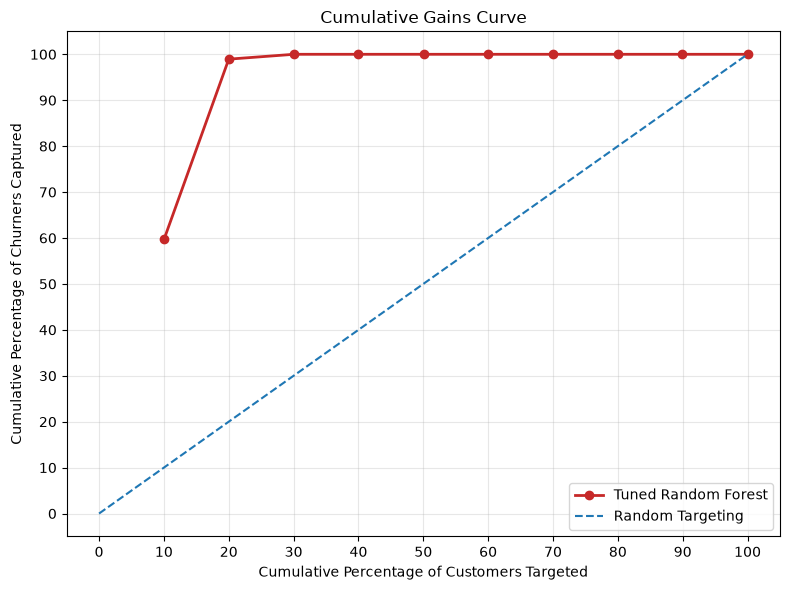

In [33]:
# Plot the cumulative percentage of churners captured
plt.figure(figsize=(8, 6))

plt.plot(
    decile_summary["Cumulative_Customer_Percentage"],
    decile_summary["Cumulative_Churner_Percentage"],
    marker="o",
    linewidth=2,
    label="Tuned Random Forest",
    color="#C62828" 
)

# Add the random-targeting baseline
plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    linewidth=1.5,
    label="Random Targeting"
)

plt.title("Cumulative Gains Curve")
plt.xlabel("Cumulative Percentage of Customers Targeted")
plt.ylabel("Cumulative Percentage of Churners Captured")
plt.xticks(range(0, 101, 10))
plt.yticks(range(0, 101, 10))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The cumulative gains curve shows how many actual churners are captured as the company progressively targets customers with the highest predicted churn probability.

By targeting only the top 10% of customers, the model captures approximately 59.8% of all churners. **Expanding the campaign to the top 20% increases churner coverage to approximately 98.9%**, while the top 30% captures all churners in the test set.

The model curve remains far above the random-targeting baseline, confirming that the ranking is highly effective. From a business perspective, **the top 20% of customers represents the most efficient intervention segment**, because it captures almost all at-risk customers while limiting retention costs.

### Feature Importance and Model Interpretation

Feature importance is extracted from the tuned Random Forest to identify the **variables that contribute most to churn prediction.**

The importance score indicates how useful each feature is for reducing classification uncertainty across the decision trees. It identifies strong predictive drivers, although it does not prove that these variables directly cause churn.

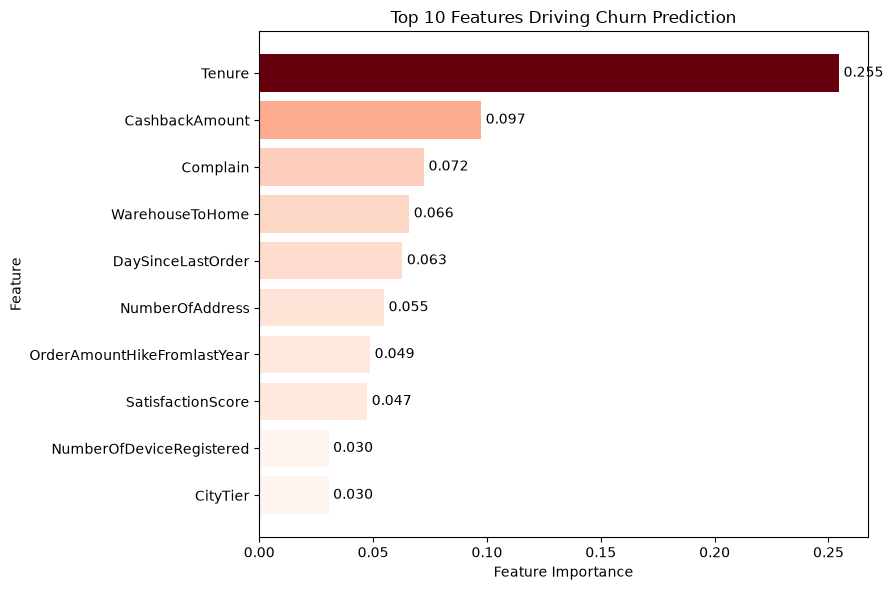

In [34]:
# Extract and rank feature importance scores
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_random_forest.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Select the ten most important features
top_features = feature_importance.head(10)

# Sort them in ascending order for a horizontal bar chart
top_features_plot = top_features.sort_values(
    by="Importance",
    ascending=True
)

# Create a red gradient based on feature importance
importance_norm = plt.Normalize(
    top_features_plot["Importance"].min(),
    top_features_plot["Importance"].max()
)

importance_colors = [
    plt.cm.Reds(importance_norm(value))
    for value in top_features_plot["Importance"]
]

# Plot the ten most important churn predictors
plt.figure(figsize=(9, 6))

bars = plt.barh(
    top_features_plot["Feature"],
    top_features_plot["Importance"],
    color=importance_colors
)

# Add importance values at the end of each bar
for bar in bars:
    plt.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.3f}",
        va="center"
    )

plt.title("Top 10 Features Driving Churn Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

- `Tenure` is the most important predictor by a wide margin, confirming that **the stage of the customer relationship strongly influences churn risk**. The exploratory analysis showed that customers in their first three months have the highest churn rate.

- `CashbackAmount` is the second most influential feature, indicating that **cashback behavior helps the model distinguish customers with different churn profiles**. However, feature importance alone does not indicate whether higher or lower cashback increases risk, so its direction requires further analysis.

- `Complain` is the third most important predictor. Customers who raised a complaint showed a churn rate of 31.7%, compared with 10.9% among customers without complaints.

These importance scores represent predictive relevance and should not be interpreted as proof of causality.

In [35]:
# Divide cashback amount into quartiles
df_clean["CashbackGroup"] = pd.qcut(
    df_clean["CashbackAmount"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

# Calculate churn rate by cashback group
cashback_churn_rate = (
    df_clean.groupby("CashbackGroup", observed=False)["Churn"]
    .mean()
    .mul(100)
    .reset_index()
)

cashback_churn_rate

,CashbackGroup,Churn
0,Low,25.035562
1,Medium-Low,19.829424
2,Medium-High,11.530249
3,High,10.953058


## Marketing Recommendations and Final Conclusions

The model identifies **three main churn risk drivers: low customer tenure, cashback behavior and recent complaints.**

Customers in their first months are especially vulnerable, while complaints represent a strong and consistent churn signal. Cashback amount also contributes meaningfully to prediction and should therefore be used to personalize retention incentives.

A targeted retention campaign should focus on **customers in the first two risk deciles**, since this group contains almost all likely churners. Recommended actions include:

- proactive onboarding support for new customers;
- immediate customer-service outreach after a complaint;
- personalized cashback or coupon offers based on customer value and purchase behavior;
- reactivation messages for customers showing prolonged inactivity.

This strategy allows the company to prioritize the highest-risk customers, reduce unnecessary campaign costs and improve retention efficiency.

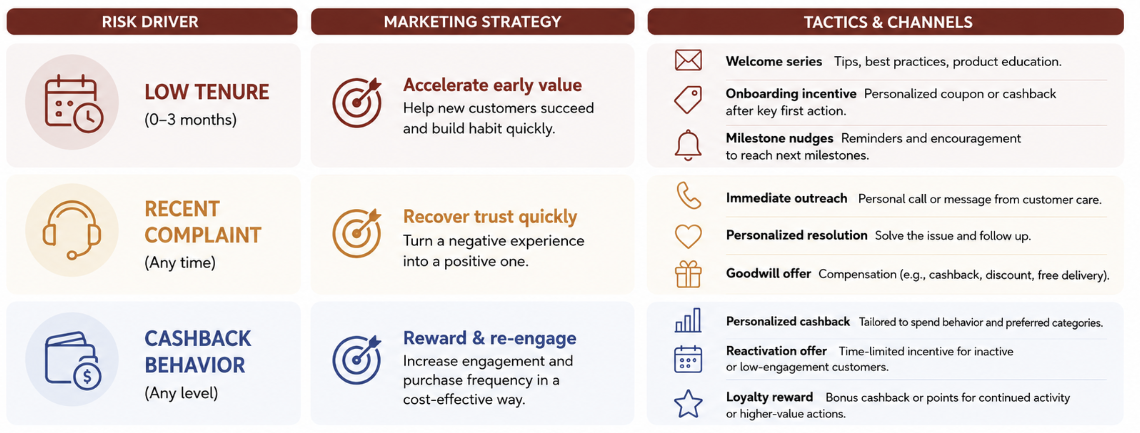

In [36]:
from IPython.display import Image, display
display(
    Image(
        filename="photo2.png",
        width=1400
    )
)

The tuned Random Forest achieved strong predictive performance and successfully concentrated almost all churners within **the top 20% of predicted-risk customers.** The model therefore provides both accurate churn prediction and a practical basis for targeted marketing decisions. However, the results should be monitored over time and validated on future customer data before full deployment.